# Fine-tuning a Vision Transformer on CIFAR-10 with PyTorch Lightning

This notebook demonstrates how to fine-tune a pretrained Vision Transformer (ViT) on the CIFAR-10 image-classification dataset. It uses Hugging Face Transformers for the pretrained model and image-processing configuration, torchvision for data preparation and augmentation, and PyTorch Lightning to organize the training loop, validation metrics, device placement, logging, and early stopping. The workflow progresses from preparing model-compatible images to defining data loaders, wrapping ViT in a Lightning module, and training the classifier on a GPU.

In [2]:
from transformers import ViTImageProcessor

# Load the preprocessing settings used when the pretrained ViT was created.
processor = ViTImageProcessor.from_pretrained("google/vit-base-patch16-224-in21k")
# Reusing these values keeps CIFAR-10 inputs compatible with the pretrained model.
image_mean = processor.image_mean
image_std = processor.image_std
size = processor.size['height']

In [3]:
processor

ViTImageProcessor {
  "do_normalize": true,
  "do_rescale": true,
  "do_resize": true,
  "image_mean": [
    0.5,
    0.5,
    0.5
  ],
  "image_processor_type": "ViTImageProcessor",
  "image_std": [
    0.5,
    0.5,
    0.5
  ],
  "resample": 2,
  "rescale_factor": 0.00392156862745098,
  "size": {
    "height": 224,
    "width": 224
  }
}

In [26]:
from torchvision import datasets
from torchvision.transforms import v2
import torch

# Training-time augmentation creates varied 224 x 224 views of each small CIFAR-10 image.
train_transform = v2.Compose([
    v2.RandomResizedCrop(size),
    v2.RandomHorizontalFlip(),
    v2.ToImage(),
    # Normalize expects floating-point values, so convert and scale bytes to [0, 1] first.
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(image_mean, image_std)
])

# Validation transforms are deterministic so every evaluation uses the same image view.
val_transform = v2.Compose([
    v2.Resize(size),
    v2.CenterCrop(size),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(image_mean, image_std)
])

train_data = datasets.CIFAR10(
    train=True,
    download=True,
    root = './data',
    transform=train_transform
)

val_data = datasets.CIFAR10(
    train=False,
    download=True,
    root='./data',
    transform=val_transform
)

In [8]:
train_data

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
                 RandomResizedCrop(size=(224, 224), scale=(0.08, 1.0), ratio=(0.75, 1.3333333333333333), interpolation=InterpolationMode.BILINEAR, antialias=True)
                 RandomHorizontalFlip(p=0.5)
                 ToImage()
                 Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5], inplace=False)
           )

In [35]:
val_data

Dataset CIFAR10
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: Compose(
                 Resize(size=[224], interpolation=InterpolationMode.BILINEAR, antialias=True)
                 CenterCrop(size=(224, 224))
                 ToImage()
                 ToDtype(scale=True)
                 Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5], inplace=False)
           )

In [39]:
# CIFAR-10 stores labels as integers; the reverse mapping makes plots easier to read.
train_data.class_to_idx
idx_to_class = {v:k for k, v in train_data.class_to_idx.items()}

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.96862745..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9764706..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9137255..1.0].


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.7490196..0.592157].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.49019605..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.81960785..0.7411766].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9607843..0.98431385].


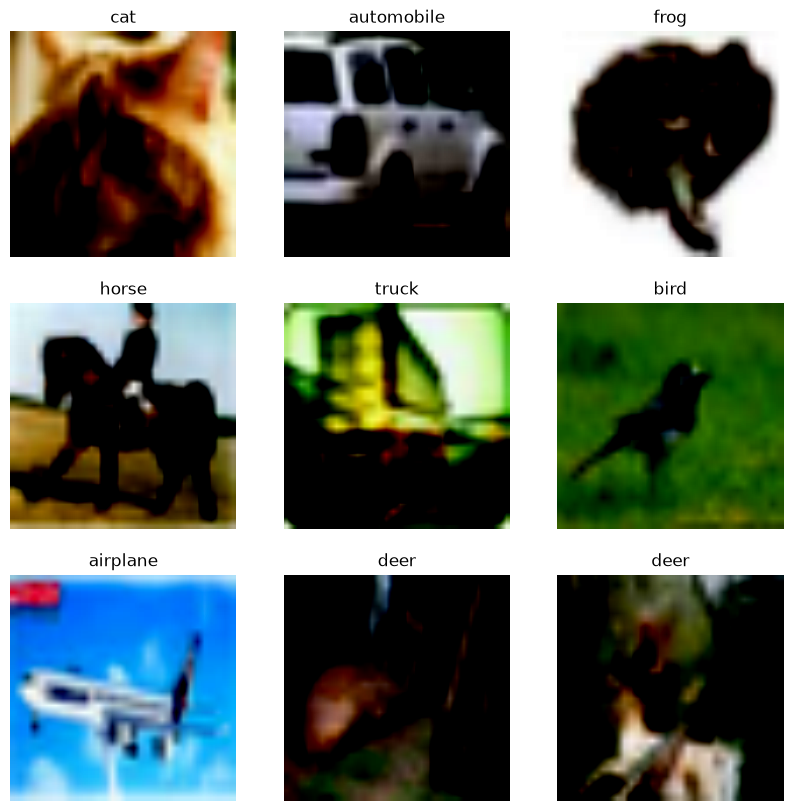

In [40]:
import matplotlib.pyplot as plt
import random

fig = plt.figure(figsize=(10, 10))
rows, cols = 3,3

# Inspect a sample of transformed validation images before starting training.
for i in range(1, rows*cols+1):
    random_index = random.randint(1,len(val_data))
    image, label = val_data[random_index]
    plt.subplot(rows, cols, i)
    plt.imshow(image.permute(1,2,0))
    plt.title(idx_to_class[label])
    plt.axis(False)
    

In [50]:
import torch
from torch.utils.data import DataLoader

def collate_fn(examples):
    """Combine individual (image, label) samples into a model-ready batch."""
    pixel_values = torch.stack([example[0] for example in examples])
    labels = torch.tensor([example[1] for example in examples])
    return {'pixel_values': pixel_values, 'labels': labels}


batch_size=4

# Build loaders that apply the custom batching logic to both dataset splits.
train_loader = DataLoader(train_data, collate_fn=collate_fn, shuffle=True, batch_size=batch_size)
val_loader = DataLoader(val_data, collate_fn=collate_fn, shuffle=True, batch_size=batch_size)

In [54]:
next(iter(train_loader))

{'pixel_values': tensor([[[[-0.7961, -0.7961, -0.7961,  ..., -0.7569, -0.7569, -0.7569],
           [-0.7961, -0.7961, -0.7961,  ..., -0.7569, -0.7569, -0.7569],
           [-0.7961, -0.7961, -0.7961,  ..., -0.7569, -0.7569, -0.7569],
           ...,
           [-0.6941, -0.6941, -0.6941,  ..., -0.5059, -0.5059, -0.5059],
           [-0.6941, -0.6941, -0.6941,  ..., -0.5059, -0.5059, -0.5059],
           [-0.6941, -0.6941, -0.6941,  ..., -0.5059, -0.5059, -0.5059]],
 
          [[-0.7882, -0.7882, -0.7882,  ..., -0.7412, -0.7412, -0.7412],
           [-0.7882, -0.7882, -0.7882,  ..., -0.7412, -0.7412, -0.7412],
           [-0.7882, -0.7882, -0.7882,  ..., -0.7412, -0.7412, -0.7412],
           ...,
           [-0.7333, -0.7333, -0.7333,  ..., -0.5529, -0.5529, -0.5529],
           [-0.7333, -0.7333, -0.7333,  ..., -0.5529, -0.5529, -0.5529],
           [-0.7333, -0.7333, -0.7333,  ..., -0.5529, -0.5529, -0.5529]],
 
          [[-0.8275, -0.8275, -0.8275,  ..., -0.7882, -0.7882, -0.7882

## Define the Lightning model

The Lightning module wraps the pretrained ViT and centralizes the forward pass, loss and accuracy calculations, training and validation steps, optimizer configuration, and data loaders.

In [ ]:
import pytorch_lightning as PL
from transformers import ViTForImageClassification
from torch.optim import AdamW
import torch.nn as nn


class ViTLightingModule(PL.LightningModule):
    def __init__(self, num_labels=len(train_data.classes)):
        super(ViTLightingModule, self).__init__()
        self.num_labels = num_labels
        # Replace the original prediction head with a new classifier for the 10 CIFAR-10 classes.
        self.vit = ViTForImageClassification.from_pretrained('google/vit-base-patch16-224-in21k',
                                                             num_labels = num_labels,
                                                             id2label = idx_to_class,
                                                             label2id = train_data.class_to_idx)
        # Do not call .cuda() here; Lightning moves the module to the configured device.

    def forward(self, pixel_values):
        output = self.vit(pixel_values)
        return output.logits

    def common_step(self, batch):
        # Share loss and accuracy computation between training and validation.
        pixel_values = batch['pixel_values']
        labels = batch['labels']
        logits = self(pixel_values)

        criterion = nn.CrossEntropyLoss()
        loss = criterion(logits, labels)
        prediction = logits.argmax(dim=1)
        correct = (prediction == labels).sum().item()
        accuracy = correct / len(batch)
        return loss, accuracy
    
    def training_step(self, batch, batch_idx):
        loss, accuracy = self.common_step(batch)
        self.log("training_loss", loss, on_epoch=True)
        self.log('training_accuracy', accuracy, on_epoch=True)
        return loss
    
    def validation_step(self, batch):
        loss, accuracy = self.common_step(batch)
        self.log("validation_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log('validation_accuracy', accuracy, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def configure_optimizers(self):
        # AdamW is commonly used to fine-tune transformer models.
        return AdamW(self.parameters(), lr=5e-5)

    def train_dataloader(self):
        return train_loader

    def val_dataloader(self):
        return val_loader

In [ ]:
# Launch TensorBoard so Lightning metrics can be monitored during training.
%load_ext tensorboard
%tensorboard --logdir lightning_logs/

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 260456), started 0:09:19 ago. (Use '!kill 260456' to kill it.)

## Train the model

The trainer uses one GPU, runs for at most 10 epochs, and configures early stopping. The callback's monitor name must match a metric logged by the Lightning module.

In [69]:
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import EarlyStopping

# Configure the early-stopping rule for the metric named by monitor.
early_stop_callback = EarlyStopping(
    monitor='val_loss',
    patience=3,
    strict=False,
    verbose=False,
    mode='min'
)

# Lightning handles device placement, epoch loops, validation, and metric logging.
model = ViTLightingModule()
trainer = Trainer(accelerator='gpu', devices=1, callbacks=[early_stop_callback], max_epochs=10, min_epochs=5)

trainer.fit(model)

Loading weights: 100%|██████████| 198/198 [00:00<00:00, 1273.76it/s]
[transformers] ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing

┏━━━┳━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━┳━━━━━━━┓
┃   ┃ Name ┃ Type                      ┃ Params ┃ Mode ┃ FLOPs ┃
┡━━━╇━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━╇━━━━━━━┩
│ 0 │ vit  │ ViTForImageClassification │ 85.8 M │ eval │     0 │
└───┴──────┴───────────────────────────┴────────┴──────┴───────┘

Trainable params: 85.8 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 85.8 M                                                                                               
Total estimated model params size (MB): 343.225                                                                    
Modules in train mode: 0                                                                                           
Modules in eval mode: 165                                                                                          
Total FLOPs: 0

/home/monster/Desktop/codes/ML-Workbook/myvenv/lib/python3.12/site-packages/rich/live.py:260: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/monster/Desktop/codes/ML-Workbook/myvenv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:
21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` 
instead.

...

/home/monster/Desktop/codes/ML-Workbook/myvenv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/da
ta_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider 
increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.

/home/monster/Desktop/codes/ML-Workbook/myvenv/lib/python3.12/site-packages/pytorch_lightning/loops/fit_loop.py:538
: Found 165 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. 
If this is intentional, you can ignore this warning.


Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

/home/monster/Desktop/codes/ML-Workbook/myvenv/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3831: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


## Evaluate the model

Use the validation data to inspect how well the fine-tuned model generalizes to images it did not train on.